In [4]:
# Importing necessary Python libraries.
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Creating the data frame.
dataframe=pd.read_csv('Zomato-data-.csv')
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [6]:
 # Convert the rate column to a float by removing denominator characters.
def handle_rate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
dataframe['rate']=dataframe['rate'].apply(handle_rate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [7]:
 #Getting summary of the dataframe use df.info().
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [8]:
 # Checking for missing or null values to identify any data gaps.
print(dataframe.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


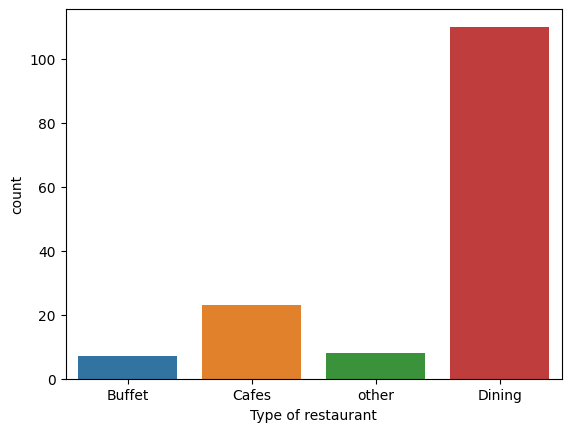

In [9]:
#the listed_in (type) column to identify popular restaurant categories.
sns.countplot(data=dataframe, x='listed_in(type)', hue='listed_in(type)')
plt.xlabel('Type of restaurant')
plt.show()


Text(0, 0.5, 'Votes')

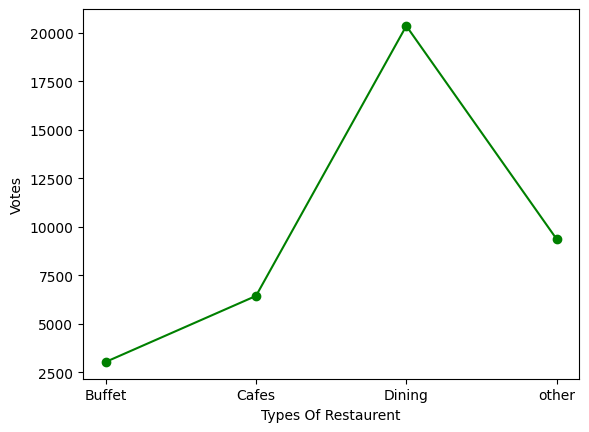

In [10]:
# Here we get the count of votes for each category
group_data=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':group_data})
plt.plot(result,c='green',marker='o')
plt.xlabel('Types Of Restaurent')
plt.ylabel('Votes')

In [14]:
#the Most Voted Restaurant
max_votes=dataframe['votes'].max()
restaurent_with_max_votes=dataframe.loc[dataframe['votes']==max_votes,'name']
print('restaurent with max votes: ')
print(restaurent_with_max_votes)

restaurent with max votes: 
38    Empire Restaurant
Name: name, dtype: object


<Axes: xlabel='online_order', ylabel='count'>

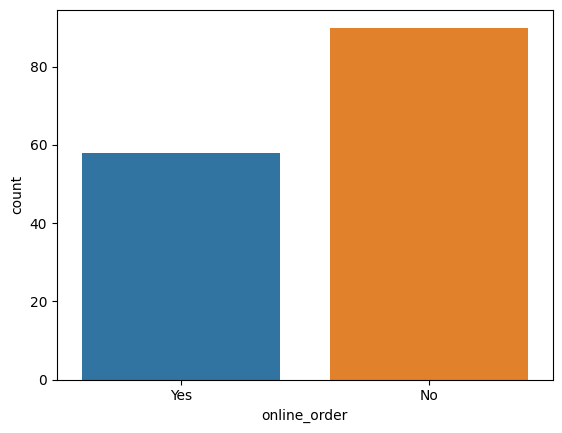

In [31]:
# the online_order column to see how many restaurants accept online orders
sns.countplot(data=dataframe,x='online_order',hue='online_order')

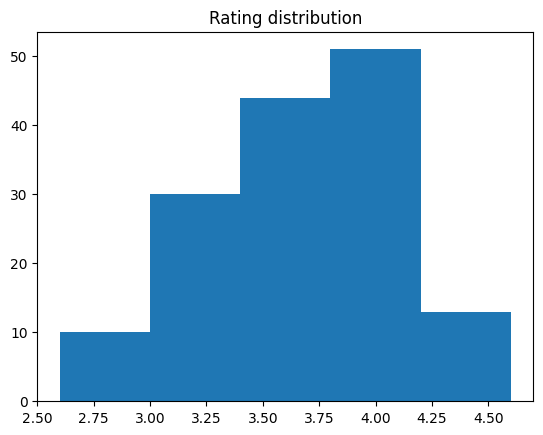

In [36]:
# the distribution of ratings from the rate column.
plt.hist(dataframe['rate'],bins=5)
plt.title('Rating distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

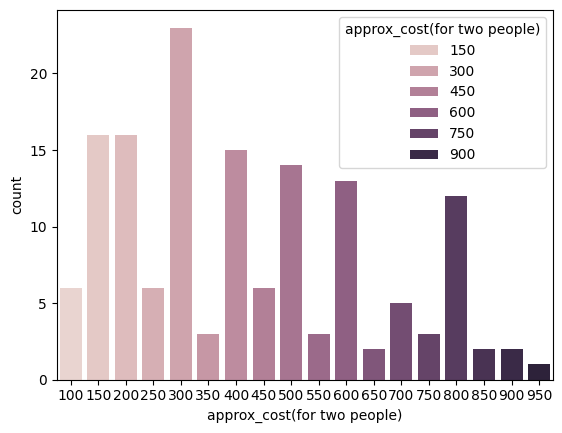

In [43]:
# the approx_cost(for two people) column to find the preferred price range.

sns.countplot(data=dataframe,x=('approx_cost(for two people)'),hue='approx_cost(for two people)')

<Axes: xlabel='online_order', ylabel='rate'>

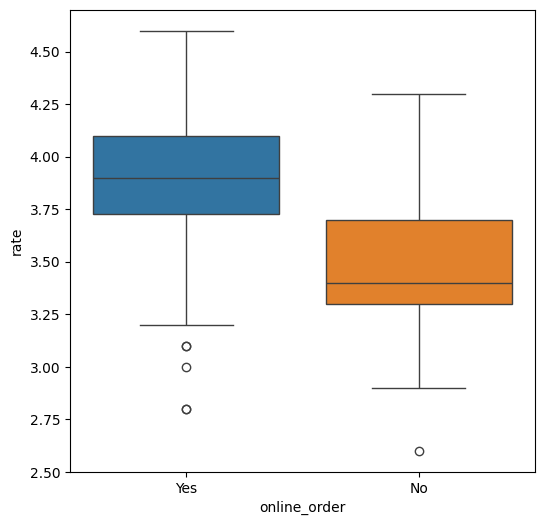

In [48]:
# ratings between restaurants that accept online orders and those that don't.
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order',y='rate',data=dataframe,hue='online_order')

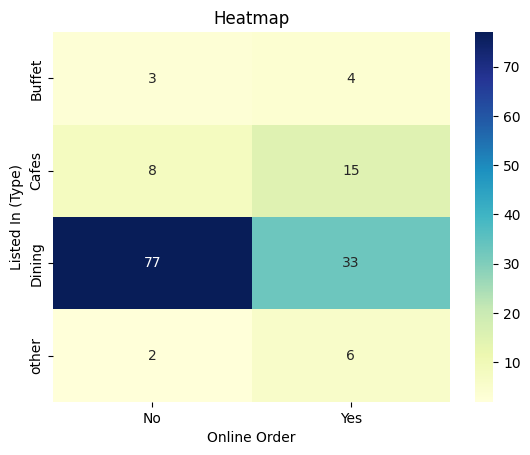

In [66]:
 # the relationship between order mode (online_order) and restaurant type (listed_in(type)).
pivot_table=dataframe.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()